In [2]:
import sys
import os
import subprocess
import numpy as np
import cv2
import time
sys.path.append("../src")

from constants import CHANNEL,LABEL_NUM

In [10]:
from PIL import Image


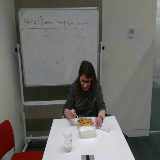

In [11]:
frame_loc = '/scratch/zeyut/EatSense/VideoData_eatSense_5hz/train_set/20230110_122933/frame_000027.ppm'
Image.open(frame_loc).convert('RGB')

In [4]:
import glob

In [24]:
video_frame_loc = '/scratch/zeyut/EatSense/VideoData_eatSense_8hz/test_set/'
video_list = glob.glob(video_frame_loc+'202*')


In [25]:
len_list = [len([f for f in os.listdir(video_list[i]) if f.endswith('.ppm')]) for i in range(len(video_list))]

In [26]:
max(len_list)

8308

In [35]:
5250/5

1050.0

In [33]:
17.5*60*5

5250.0

In [78]:
import pandas
csvFile = pandas.read_csv('/zfs/mhealth/zeyut/eat_detection/EatSense/all_2d3d_true/20210518_230219.csv')
len_list = []
for csv_path in os.listdir(video_frame_loc):
    csvFile = pandas.read_csv(f'/zfs/mhealth/zeyut/eat_detection/EatSense/all_2d3d_true/{csv_path}.csv')
    cur_l = len(csvFile['Action'].to_numpy())
    cur_fps = csvFile['fps'][0]
    len_list.append(cur_l/cur_fps)

(3664,)


In [81]:
np.mean(len_list)/60

5.849823045267489

In [7]:
1469/8

183.625

In [8]:
5507/30

183.56666666666666

In [114]:
240+43

283

In [115]:
len_list[9]

175.73333333333332

In [128]:
5527/30

184.23333333333332

In [129]:
1474/8-60*3

4.25

In [122]:
video_list[22]

'/scratch/zeyut/EatSense/eatSense_rawFrames_8hz/20210620_150313'

In [69]:
l_list = [len([f for f in os.listdir(video_frame_loc) if f.endswith('.ppm')]) for video_frame_loc in video_list]

In [84]:
video_list[6]

'/scratch/zeyut/EatSense/eatSense_rawFrames_8hz/20210603_130948'

In [123]:
[l1-l2/8 for l1,l2 in zip(len_list,l_list)]

[-0.23333333333332007,
 0.01666666666665151,
 -0.2916666666666856,
 -0.125,
 -0.20833333333331439,
 -0.06666666666666288,
 -8.199999999999989,
 -0.26666666666667993,
 -0.125,
 -107.39166666666668,
 -2.916666666666657,
 -7.524999999999977,
 -0.15833333333335986,
 -0.15833333333335986,
 -0.25833333333333997,
 -0.125,
 -0.024999999999977263,
 -5.3250000000000455,
 -0.125,
 -5.150000000000006,
 -0.8249999999999886,
 -0.46666666666664014,
 -385.73333333333335,
 -2.9250000000000114,
 -1.4916666666666742,
 -0.05833333333333712,
 -8.425000000000011,
 -0.19166666666666288,
 -5.524999999999977,
 -2.09166666666664,
 -0.25833333333332575,
 -0.19166666666671972,
 -60.02499999999998,
 -0.15833333333333144,
 -21.258333333333326,
 -0.08333333333337123,
 0.8416666666666686,
 -11.558333333333337,
 -5.491666666666674,
 -63.9083333333333,
 -251.02499999999998,
 -0.1416666666666515,
 -12.308333333333337,
 3.6499999999999773,
 -0.27499999999997726,
 -0.10000000000002274,
 -0.10833333333332007,
 -109.4500000

In [121]:
np.where(np.array([l1-l2/8 for l1,l2 in zip(len_list,l_list)])+100<0)[0]

array([ 9, 22, 40, 47, 70, 75, 78, 82])

In [74]:
np.mean(l_list)/8/60

6.120262345679012

In [82]:
a = [1265, 402, 23670]
a/(np.sum(a))

array([0.04992698, 0.01586612, 0.93420689])

In [32]:
frame_names = [f for f in os.listdir(video_frame_loc) if f.endswith('.ppm')]
frame_names.sort(reverse=False)
timestamp = 0.0
gesture_idx = 0

In [48]:
2*60+51

171

In [50]:
4768/15/2

158.93333333333334

In [51]:
frameNo = 1
for frame_name in frame_names:
    # update gesture idx to match current time step
    while timestamp > gesture_ends[gesture_idx]:
        gesture_idx += 1

    if timestamp >= gesture_starts[gesture_idx] and timestamp <= gesture_ends[gesture_idx]:
        cur_ges = gesture_types[gesture_idx]
    else:
        cur_ges = 'non-intake'


In [4]:
import pandas
csvFile = pandas.read_csv('/zfs/mhealth/zeyut/eat_detection/EatSense/all_2d3d_true/20210518_230219.csv')
print(csvFile['Action'].to_numpy().shape)

(3664,)


In [57]:
3663/15*5

1221.0

In [5]:
def load_gt_boundaries(frame_gt):
    ''' Identify temporal boundaries ('eat it' and 'drink') from frame-wise labels '''
    ''' Unit: ms '''
    gesture_starts, gesture_ends, gesture_types = [], [], []
    timestamp = 0
    while timestamp < len(frame_gt):
        if frame_gt[timestamp] == 'eat it':
            gesture_starts.append(timestamp*1000./15.) 
            gesture_types.append('bite')
            while timestamp < len(frame_gt) and frame_gt[timestamp] == 'eat it':
                timestamp += 1
            gesture_ends.append((timestamp-1)*1000./15.)
        elif frame_gt[timestamp] == 'drink':
            gesture_starts.append(timestamp*1000./15.) 
            gesture_types.append('drink')
            while timestamp < len(frame_gt) and frame_gt[timestamp] == 'drink':
                timestamp += 1
            gesture_ends.append((timestamp-1)*1000./15.)
        else:
            timestamp += 1
    return gesture_starts, gesture_ends, gesture_types

In [8]:
csvFile['Action'].to_numpy()


array(['other', 'other', 'other', ...,
       'pick food from utensil with tools in both hands',
       'pick food from utensil with tools in both hands',
       'pick food from utensil with tools in both hands'], dtype=object)

In [11]:
gesture_starts, gesture_ends, gesture_types = load_gt_boundaries(csvFile['Action'].to_numpy())

In [20]:
gesture_starts[-1]*8/1000

1875.7333333333333

In [13]:
[round(start*8/1000.) for start in gesture_starts]

[56,
 174,
 310,
 414,
 521,
 676,
 785,
 979,
 1075,
 1189,
 1324,
 1479,
 1597,
 1743,
 1876]

In [26]:
1882/8

235.25

In [25]:
3663/15

244.2

In [29]:
244534/(1000./8)

1956.272

### Calculate the durations before/after gestures

In [5]:
class MedianMeter(object):
    """Computes and stores the median and current value"""

    def __init__(self):
        self.reset()

    def reset(self):
        self.val = 0
        self.list = []
        self.median = 0
        self.count = 0
        self.index = 0
    def update(self, val, n=1):
        self.val = val
        self.list.append(val)
        self.count += 1
        self.list.sort()        
        self.index = (self.count - 1) // 2
        if (self.count % 2):
            self.median = self.list[self.index]
        else:
            self.median = (self.list[self.index] + self.list[self.index+1])/2.0
            
class AverageMeter(object):
    """Computes and stores the average and current value"""

    def __init__(self):
        self.reset()

    def reset(self):
        self.val = 0
        self.sum = 0
        self.avg = 0
        self.count = 0
    def update(self, val):
        self.val = val
        self.sum += val
        self.count += 1
        self.avg = self.sum/self.count


In [21]:
mean_drink = AverageMeter()
mean_bite = AverageMeter()
mean_rec = AverageMeter()
gt_loc = "/zfs/mhealth/zeyut/eat_detection/CafeteriaData/"
video_list = open("/zfs/mhealth/zeyut/eat_detection/CafeteriaData/DATA_FILENAMES.txt","r")

for video in video_list:
    gesture_start = []
    gesture_end = []
    gesture_type = []
    cur_gt_loc = os.path.join(gt_loc,video.split("/")[0],video.split("/")[1],"gesture_union.txt")
    if os.path.exists(cur_gt_loc):
        f_gt_ges = open(cur_gt_loc,"r")
        rec_start = -1
        for line in f_gt_ges.readlines():
            info = line.split("\n")[0].split("\t")[0:3]
            gesture_type,gesture_start,gesture_end = info[0], int(info[1]), int(info[2])
            if gesture_type == 'bite':
                mean_bite.update(gesture_end-gesture_start)
            if gesture_type == 'drink':
                mean_drink.update(gesture_end-gesture_start)
            if rec_start < 0:
                rec_start = gesture_start
        rec_end = gesture_end
        mean_rec.update(rec_end-rec_start)

In [22]:
print(f"# bites: {mean_bite.count}")
print(f"# drinks: {mean_drink.count}")
print(f"average bite duration: {mean_bite.avg/15} sec")
print(f"average drink duration: {mean_drink.avg/15} sec")
print(f"average rec duration: {mean_rec.avg/15} sec")

print(f"average bite duration / average rec duration: {mean_bite.avg/mean_rec.avg}")
print(f"average drink duration / average rec duration: {mean_drink.avg/mean_rec.avg}")

# bites: 18462
# drinks: 2182
average bite duration: 2.3270934893294335 sec
average drink duration: 5.804613504430187 sec
average rec duration: 735.6525956284153 sec
average bite duration / average rec duration: 0.003163304939258135
average drink duration / average rec duration: 0.007890427545452649


In [ ]:
gt_loc = "../CafeteriaData/"
f_list = open("./videolist.txt","r")
video_list = map(lambda x:x.split("\n")[0],f_list.readlines())
f_list.close()
median_drink_pre =  MedianMeter()
median_drink_after = MedianMeter()
median_bite_pre =  MedianMeter()
median_bite_after = MedianMeter()

for video in video_list:
    gesture_start = []
    gesture_end = []
    gesture_type = []
    f_gt_ges = open(os.path.join(gt_loc,video.split("_")[0],video.split("_")[1],"gesture_union.txt"),"r")
    for line in f_gt_ges.readlines():
        info = line.split("\n")[0].split("\t")[0:3]
        gesture_type.append(info[0])
        gesture_start.append(int(info[1]))
        gesture_end.append(int(info[2]))

    f_gt_ges.close()  
    
    gt_drinks = []
    gt_bites = []
    f_gt = open(os.path.join(gt_loc,video.split("_")[0],video.split("_")[1],"gt_union.txt"),"r")
    for line in f_gt.readlines():
        line = line.split("\n")[0]
        try:
            cur_idx = int(line.split("\t")[1])
        except:
            print(video,line)
        cur_container = line.split("\t")[4]
        if cur_container in ["bowl","plate"]:
            gt_bites.append(cur_idx)
        elif cur_container in ["mug","glass"]:
            gt_drinks.append(cur_idx)
    f_gt.close()    
    drink_idx = 0
    bite_idx = 0
    for start,end,label in zip(gesture_start,gesture_end,gesture_type):
        if label in ["bite","drink"]:
            for drink_loc in gt_drinks:
                if drink_loc >= start and drink_loc <= end:
                    # calculate the median offset duration before a drink gesture
                    median_drink_pre.update(drink_loc-start)
                    # calculate the median offset duration after a drink gesture
                    median_drink_after.update(end-drink_loc)
                    break
            for bite_loc in gt_bites:
                if bite_loc >= start and bite_loc <= end:
                    # calculate the median offset duration before a drink gesture
                    median_bite_pre.update(bite_loc-start)
                    # calculate the median offset duration after a drink gesture
                    median_bite_after.update(end-bite_loc)
                    break                    
        


p011_c2 						
p048_c1 					


KeyboardInterrupt: 

In [4]:
print(f"offset before bites: {median_bite_pre.median/15*1000:.02f} ms")
print(f"offset after bites: {median_bite_after.median/15*1000:.02f} ms")
print(f"offset before drinks: {median_drink_pre.median/15*1000:.02f} ms")
print(f"offset after drinks: {median_drink_after.median/15*1000:.02f} ms")

offset before bites: 1000.00 ms
offset after bites: 1066.67 ms
offset before drinks: 2066.67 ms
offset after drinks: 3200.00 ms


In [18]:
print(f"ideal frames per bite:{(median_bite_pre.median+median_bite_after.median)/15*8:.0f}")
print(f"ideal frames per drink:{(median_drink_pre.median+median_drink_after.median)/15*8:.0f}")

ideal frames per bite:17
ideal frames per drink:42


### The number of new added gestures and corresponding frames

In [81]:
gt_loc = "D:/eat_detection/all_labels/"
video_list = [f for f in os.listdir(gt_loc)]
bite_count = 0
drink_count = 0
bite_frame_count = 0
drink_frame_count = 0
for video_idx in video_list:
    subject = video_idx
    start_idx = -1
    #subject = str.split(video_idx,"_")[0]
    f_gt = open(f"{gt_loc}{video_idx}/gt_ges_3labels.txt","r")
    for line in f_gt.readlines():
        info = str.split(str.split(line, "\n")[0], "\t") 
        if info[0] == "bite":
            bite_count += 1
            bite_frame_count += int(info[2]) - int(info[1])
        if info[0] == "drink":
            drink_count += 1 
            drink_frame_count += int(info[2]) - int(info[1])

print(f"new number of drink: {drink_count}")
print(f"new number of bite: {bite_count}")

print(f"duration of drink: {drink_frame_count} frames")
print(f"duration of bite: {bite_frame_count} frames")

new number of drink: 3510
new number of bite: 19632
duration of drink: 150022
duration of bite: 359223


In [82]:
gt_loc = "D:/eat_detection/all_labels/"
video_list = [f for f in os.listdir(gt_loc)]
bg_frame_count = 0
for video_idx in video_list:
    subject = video_idx
    #subject = str.split(video_idx,"_")[0]
    f_gt = open(f"{gt_loc}{video_idx}/gt_ges_3labels.txt","r")
    content = f_gt.readlines()
    end_idx = int(str.split(str.split(content[-1], "\n")[0], "\t")[2] )
    start_idx = int(str.split(str.split(content[0], "\n")[0], "\t")[1] )

    bg_frame_count += end_idx - start_idx
print(f"duration of background: {bg_frame_count} frames")


duration of background: 2573725 frames


In [44]:
ori_gt_loc = "D:/OneDrive/PhD/work/eat_detection/CafeteriaData/"
bite_count_ori = 0
drink_count_ori = 0
new_bite_count = 0
new_drink_count = 0
for video_idx in video_list:
    subject = str.split(video_idx,"_")[0]
    course_idx = str.split(video_idx,"_")[1]
    f_gt = open(f"{ori_gt_loc}{subject}/{course_idx}/gesture_union.txt","r")    
    for line in f_gt.readlines():
        info = str.split(str.split(line, "\n")[0], "\t") 
        if info[0] == "bite":
            bite_count_ori += 1
            #print(info[0])
        if info[0] == "drink":
            drink_count_ori += 1 
print(f"original number of drink: {drink_count_ori}")
print(f"original number of bite: {bite_count_ori}")

original number of drink: 2175
original number of bite: 18399


In [45]:
print(f"added bite: {bite_count - bite_count_ori}")
print(f"added drink: {drink_count - drink_count_ori}")
print(f"Ideally added bite frames: {17*(bite_count - bite_count_ori)}")
print(f"Ideally added drink frames: {42*(drink_count - drink_count_ori)}")

added bite: 1233
added drink: 1335
Ideally added bite frames: 20961
Ideally added drink frames: 56070


Actually added frames for bite and drink: 16619, and 49064

Actually added durations for bite and drink: 2077, and 6133

In [60]:
2077/60

34.61666666666667

In [6]:
(7528/15*1000+13360)/1000/60

8.587111111111112

### Debug the function for adding new gestures

In [3]:
def load_gt(gesture_gt_loc,intake_gt_loc,video_sync_offset):
    
    """ Load ground truths from txt files. txt files only include gestures using dominant hands.
        Then find unlabeled drink/bite gestures using non-dominant hands, 
        by looking at near timestamps when using varies tools (mug, glass, etc.) from 'gt.txt' files.
        Once a unlabeled gesture is found:
        the starting timestamp is assumed to be gesture's location - PRE_INTAKE_DURATION
        the ending timestamp is assumed to be gesture's location + AFTER_INTAKE_DURATION
        Where gesture's location is the timestamp when the intaking tool touchs the subject's mouth
    """
    def timeidx_to_ms(timeidx):
        return (int)(timeidx * 1000.0 / 15.0 + video_sync_offset);	# 1000/15 converts 15Hz data to milliseconds 
        
    def load_intake_idxs(intake_gt_loc):
        """
        load the central time idxs of intake gestures from gt_union.txt. time idxs are in 15 hz.
        """
        bite_locations = []
        drink_locations = []
        f_intake_gt = open(intake_gt_loc, "r")
    
        for line in f_intake_gt.readlines():
            cur_container = str.split(line, "\t")[4]
            if cur_container == '':
                continue
            cur_idx = int(str.split(line, "\t")[1])
            if cur_container in ["bowl","plate"]:
                bite_locations.append(cur_idx)
            elif cur_container in ["mug","glass"]:
                drink_locations.append(cur_idx)
        f_intake_gt.close()
        return bite_locations, drink_locations       
         
    def record_missed_gesture(gesture_info,start_time,end_time):
        # create gestures for those unlabeled intake gestures, with statistically obtained pre and after offset duration.
        # consider the background as non-intake.
        cur_start_time = start_time
        for idx, intake in enumerate(unlabeled_intakes):
            pivot_time = intake[0]
            label = intake[1]
            # check if there is a piece of background before the current intake gesture 
            if pivot_time - PRE_INTAKE_DURATION[label] > cur_start_time:        
                gesture_types.append("non_intake")
                gesture_starts.append(cur_start_time)
                # move backward by 1 timestamp in 15 hz, 
                # so that the gesture_end do not overlap with the start time of the next gesture
                # the same strategy applies in the follows.
                gesture_ends.append(int(pivot_time - PRE_INTAKE_DURATION[label] - 1000/15)) 
                
            gesture_types.append(label)
            gesture_starts.append(max(pivot_time - PRE_INTAKE_DURATION[label], cur_start_time)) 
            
            if idx == len(unlabeled_intakes) - 1:
                if pivot_time + AFTER_INTAKE_DURATION[label] > end_time:
                    gesture_ends.append(end_time)
                else:
                    gesture_ends.append(int(pivot_time + AFTER_INTAKE_DURATION[label] - 1000/15))
                    # there is a piece of background after the last intake gesture 
                    gesture_types.append("non_intake")
                    gesture_starts.append(pivot_time + AFTER_INTAKE_DURATION[label])
                    gesture_ends.append(end_time)                   
            else:
                # meet the requirement for gestures' pre_intake_duration first.
                gesture_ends.append(min(pivot_time + AFTER_INTAKE_DURATION[label], \
                                        int(unlabeled_intakes[idx+1][0] - PRE_INTAKE_DURATION[unlabeled_intakes[idx+1][1]]- 1/15)))   
            cur_start_time = gesture_ends[-1]    
        
    bite_locations, drink_locations = load_intake_idxs(intake_gt_loc)
    
    f_gt = open(gesture_gt_loc,'r')
    is_start = 1  # a flag used to jump to the first labeled gesture in videos
    gesture_starts = []
    gesture_ends = []
    gesture_types = []
    pre_end = 0
    for line in f_gt.readlines():
        label,cur_start,cur_end = str.split(line,"\t")[0:3]
        cur_start = int(cur_start)
        cur_end = int(str.split(cur_end,"\n")[0])

        #Find unlabeled video pieces
        if is_start == 0:
            if cur_start > pre_end + 1:
                unlabel_start = pre_end + 1
                unlabel_end = cur_start - 1
                # check if any drinking/eating gesture using non-dominant hand exists in rest/other gestures   
                # firstly, find the nearest bite&drink event after the unlabel_start          
                bite_idx = 0
                drink_idx = 0
                unlabeled_intakes = []
                while (1):
                    if bite_idx >= len(bite_locations)-1:
                        break
                    if bite_locations[bite_idx] < unlabel_start:
                        bite_idx += 1
                    elif bite_locations[bite_idx] <= unlabel_end:
                        unlabeled_intakes.append([timeidx_to_ms(bite_locations[bite_idx]),"bite"])
                        bite_idx += 1
                    else:
                        break
                while (1):
                    if drink_idx >= len(drink_locations)-1:
                        break
                    if drink_locations[drink_idx] < unlabel_start:
                        drink_idx += 1
                    elif drink_locations[drink_idx] <= unlabel_end:
                        unlabeled_intakes.append([timeidx_to_ms(drink_locations[drink_idx]),"drink"])
                        drink_idx += 1
                    else:
                        break
                if len(unlabeled_intakes) != 0:
                    unlabeled_intakes.sort(key=lambda x:x[0])
                    record_missed_gesture(unlabeled_intakes,timeidx_to_ms(unlabel_start),timeidx_to_ms(unlabel_end))
                else:
                    gesture_starts.append(timeidx_to_ms(unlabel_start)) # data index of start of gesture
                    gesture_ends.append(timeidx_to_ms(unlabel_end)) # data index of end of gesture
                    gesture_types.append("non_intake") # data labeled as non_intake
        if label in ["rest","other","utensiling"]:
            # check if any drinking/eating gesture using non-dominant hand exists in rest/other gestures   
            # firstly, find the nearest bite&drink event after the unlabel_start          
            bite_idx = 0
            drink_idx = 0
            unlabeled_intakes = []
            while (1):
                if bite_idx >= len(bite_locations):
                    break
                if bite_locations[bite_idx] < cur_start:
                    bite_idx += 1
                elif bite_locations[bite_idx] <= cur_end:
                    unlabeled_intakes.append([timeidx_to_ms(bite_locations[bite_idx]),"bite"])
                    bite_idx += 1
                else:
                    break
            while (1):
                if drink_idx >= len(drink_locations):
                    break
                if drink_locations[drink_idx] < cur_start:
                    drink_idx += 1
                elif drink_locations[drink_idx] <= cur_end:
                    unlabeled_intakes.append([timeidx_to_ms(drink_locations[drink_idx]),"drink"])
                    drink_idx += 1
                else:
                    break
                
            if len(unlabeled_intakes) != 0:
                unlabeled_intakes.sort(key=lambda x:x[0])
                record_missed_gesture(unlabeled_intakes,timeidx_to_ms(cur_start),timeidx_to_ms(cur_end))
            else:
                gesture_starts.append(timeidx_to_ms(cur_start)) # data index of start of gesture
                gesture_ends.append(timeidx_to_ms(cur_end)) # data index of end of gesture
                gesture_types.append("non_intake") # data labeled as non_intake
        else:
            # label in ["drink","bite"]
            gesture_types.append(label)
            gesture_starts.append(timeidx_to_ms(cur_start)) # data index of start of gesture
            gesture_ends.append(timeidx_to_ms(cur_end));  # data index of end of gesture  

        is_start = 0
        pre_end = cur_end
 
    f_gt.close()
    return gesture_starts, gesture_ends, gesture_types

In [4]:
gesture_gt_loc = "../CafeteriaData/p069/c3/gesture_union.txt"
intake_gt_loc = "../CafeteriaData/p069/c3/gt_union.txt"
video_sync_offset = 778
PRE_INTAKE_DURATION = {"bite":500,"drink":1000} # in ms
AFTER_INTAKE_DURATION = {"bite":500,"drink":1000} # in ms
gesture_starts, gesture_ends, gesture_types = load_gt(gesture_gt_loc,intake_gt_loc,video_sync_offset)

In [5]:
88878 - 88811 

67

In [6]:
print("\n".join([f"{i} {k} {v}" for i,k,v in zip(gesture_starts,gesture_ends,gesture_types)]))

27911 29311 bite
29378 40311 non_intake
40378 41578 non_intake
41644 43578 non_intake
43644 48844 non_intake
48911 49578 non_intake
49644 71378 non_intake
71444 72311 non_intake
72378 74644 non_intake
74711 76178 non_intake
76244 77844 non_intake
77911 78644 non_intake
78711 81578 non_intake
81644 84511 non_intake
84578 86044 non_intake
86111 86711 non_intake
86778 87811 non_intake
87878 88811 bite
88878 88911 non_intake
88978 89111 non_intake
89178 90444 non_intake
90511 92111 non_intake
92178 93711 non_intake
93778 93778 non_intake
93844 95711 bite
95778 96711 non_intake
96778 98178 non_intake
98244 102578 non_intake
102644 104844 non_intake
104911 106844 non_intake
106911 110644 bite
110711 124911 non_intake
124978 126778 non_intake
126844 128111 non_intake
128178 133111 non_intake
133178 133311 non_intake
133378 135844 bite
135911 136711 non_intake
136778 137778 non_intake
137844 139178 non_intake
139244 140244 non_intake
140311 154511 non_intake
154578 154578 non_intake
154644 156

In [41]:
ms = 88878       
video_sync_offset = 778
(ms - video_sync_offset) /1000 * 15

1321.5

In [13]:
a = [[5,"bite"],[3,"drink"],[4,"bite"],[8,"drink"]]
a.sort(key=lambda x:x[0])
a

[[3, 'drink'], [4, 'bite'], [5, 'bite'], [8, 'drink']]

In [22]:
sensor_idx = 1314
sensor_idx/15*1000+video_sync_offset

88378.0

In [92]:
offset = video_sync_offset
(487778   -offset)/1000*15

7206.99

In [4]:
f_datanames = open("../CafeteriaData/DATA_FILENAMES.txt")
datanames = f_datanames.readlines()
for dataname in datanames:
    intake_gt_loc = f"../CafeteriaData/{dataname[0:7]}/gt_union.txt"
    f_intake_gt = open(intake_gt_loc, "r")
    
    for line in f_intake_gt.readlines():
        cur_container = str.split(line, "\t")[4]
        cur_tool = str.split(line, "\t")[3]
        if cur_tool not in ["hand", "spoon", "fork"]:
            print(intake_gt_loc, cur_tool)
        '''
        if cur_container == '':
            continue
        cur_idx = int(str.split(line, "\t")[1])
        if cur_container == "bowl":
            print(intake_gt_loc)
        ''' 

../CafeteriaData/p014/c1/gt_union.txt 
../CafeteriaData/p082/c2/gt_union.txt chopsticks
../CafeteriaData/p082/c2/gt_union.txt chopsticks
../CafeteriaData/p082/c2/gt_union.txt chopsticks
../CafeteriaData/p082/c2/gt_union.txt chopsticks
../CafeteriaData/p082/c2/gt_union.txt chopsticks
../CafeteriaData/p082/c2/gt_union.txt chopsticks
../CafeteriaData/p082/c2/gt_union.txt chopsticks
../CafeteriaData/p082/c2/gt_union.txt chopsticks
../CafeteriaData/p082/c2/gt_union.txt chopsticks
../CafeteriaData/p082/c2/gt_union.txt chopsticks
../CafeteriaData/p082/c2/gt_union.txt chopsticks
../CafeteriaData/p082/c2/gt_union.txt chopsticks
../CafeteriaData/p082/c2/gt_union.txt chopsticks
../CafeteriaData/p082/c2/gt_union.txt chopsticks
../CafeteriaData/p082/c2/gt_union.txt chopsticks
../CafeteriaData/p082/c2/gt_union.txt chopsticks
../CafeteriaData/p082/c2/gt_union.txt chopsticks
../CafeteriaData/p082/c2/gt_union.txt chopsticks
../CafeteriaData/p082/c2/gt_union.txt chopsticks
../CafeteriaData/p082/c2/gt_un

### Visualize dataset

In [1]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
import os
#data_loc = "D:/eat_detection/VideoData_independent/train_set/"
#gt_loc = "D:/eat_detection/all_labels/"
data_loc = "/zfs/mhealth/zeyut/eat_detection/VideoData_independent_5hz/"
gt_loc = "/zfs/mhealth/zeyut/eat_detection/VideoData_independent_5hz/"
video_idx = "p072_c1"
video_idx = "p259_c1"

In [2]:

f_gt = open(f"{gt_loc}{video_idx}/gt_ges_3labels.txt","r")
bite_idxs = []
drink_idxs = []
for line in f_gt.readlines():
    info = str.split(str.split(line, "\n")[0], "\t") 
    if info[0] == "bite":
        bite_idxs.append([int(info[1]),int(info[2])])
    if info[0] == "drink":
        drink_idxs.append([int(info[1]),int(info[2])])
f_gt.close()


In [3]:
drink_idxs[2][0]

2777

#### Single image plot

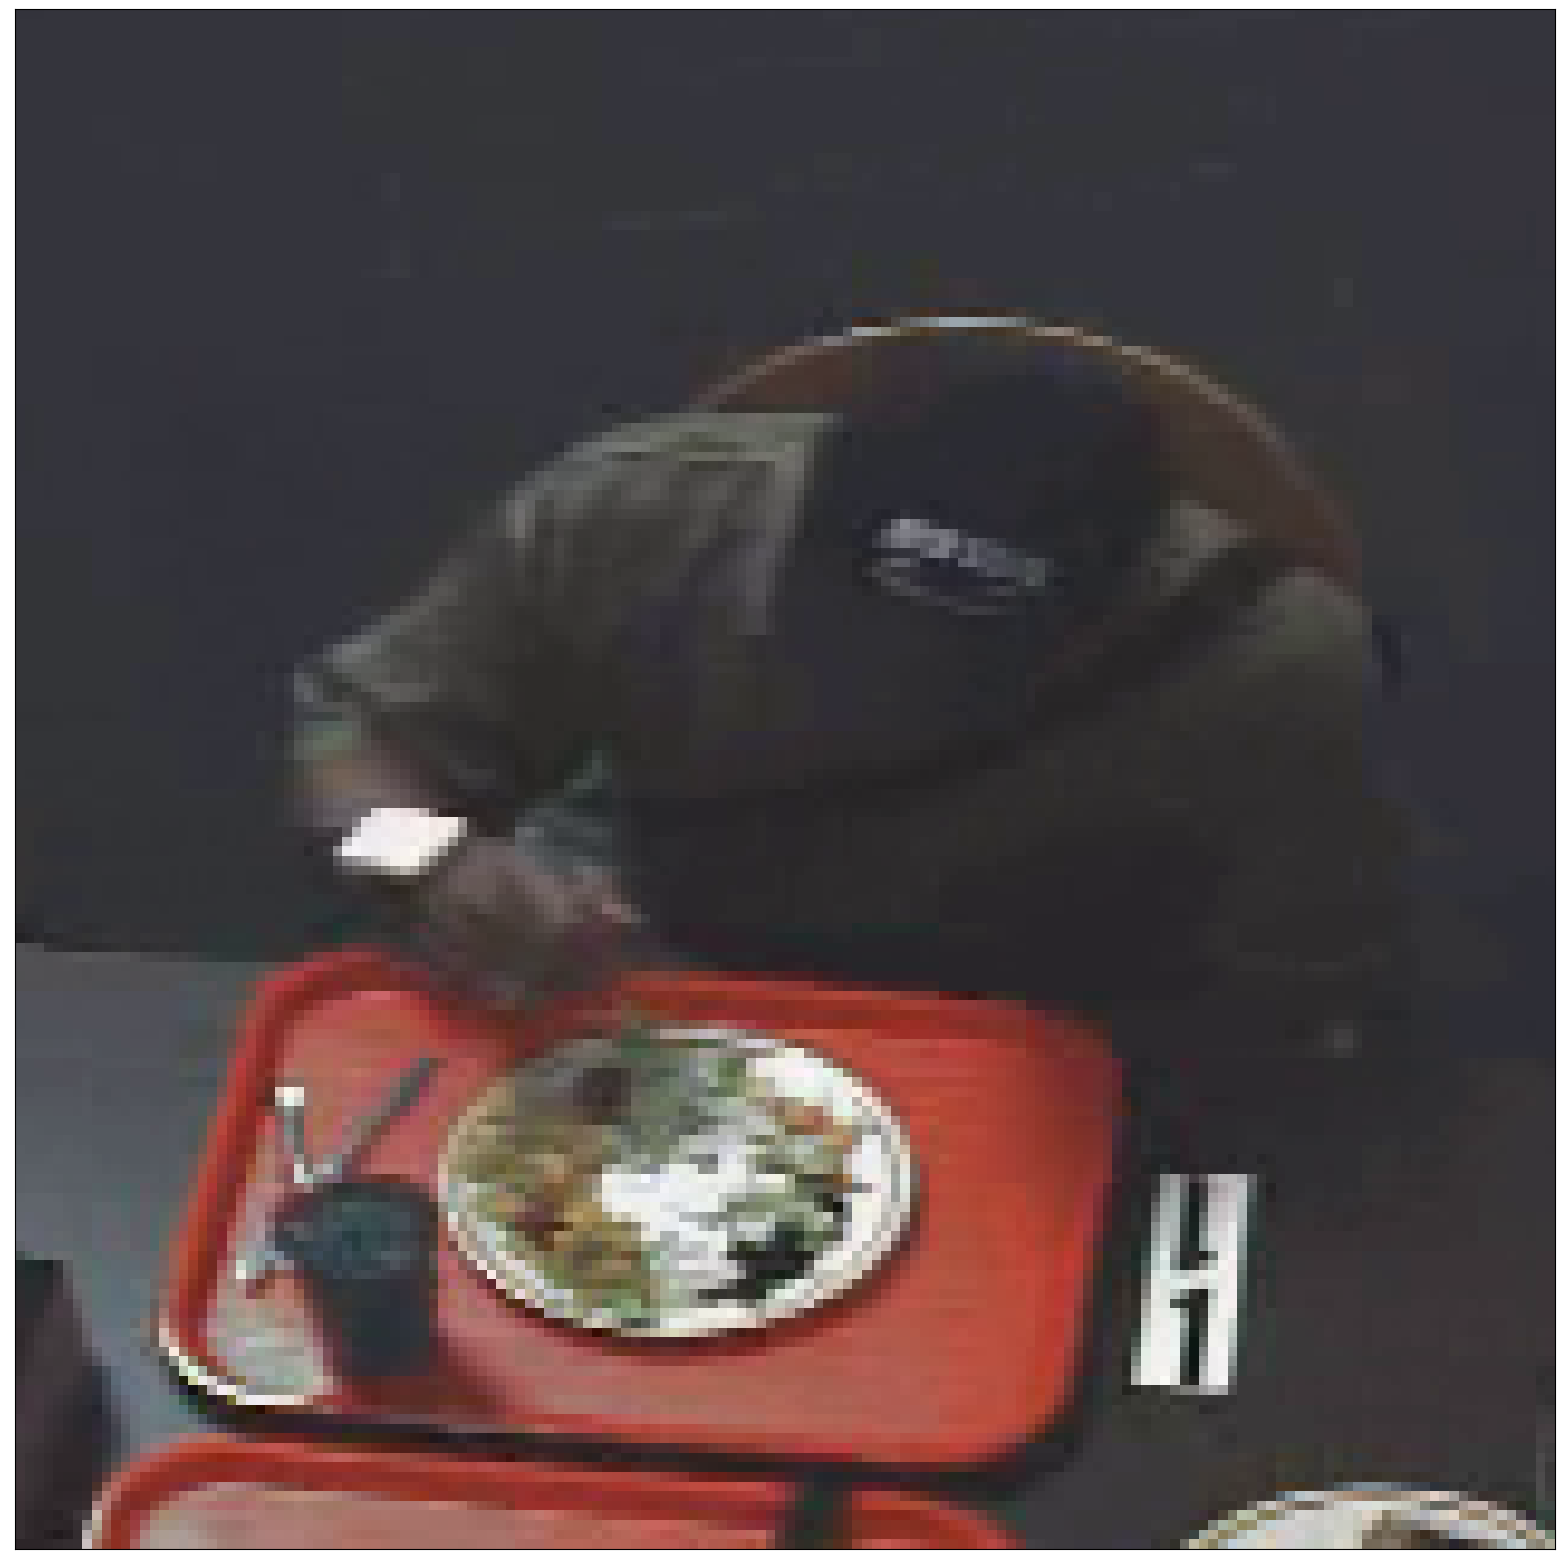

In [80]:
fig=plt.figure(figsize=(20, 20))
# p072_c1:
# Fake bite idx: 2316+9,
# Fake drink idx: 692+9
# True bite idx: 340
# True drink idx: 668


frame_idx = 340
frame = cv2.imread(f"{data_loc}{video_idx}/frame_{frame_idx:06}.ppm")
frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
plot = plt.imshow(frame)
plot.axes.get_xaxis().set_visible(False)
plot.axes.get_yaxis().set_visible(False)
plt.savefig('trueBite.pdf', format='pdf', dpi=500, bbox_inches='tight')    

#### Plot full video span

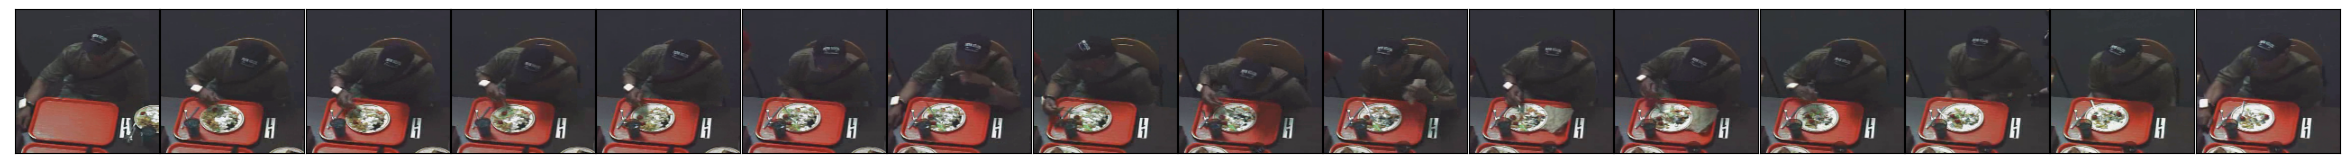

In [4]:
cols = 16
rows = 1
fig=plt.figure(figsize=(30, 5))
# Video idx: p072_c1
# frame idx range: 9 - 4410
for col_idx in range(cols):
    plt.subplot(rows,cols,col_idx+1)
    frame = cv2.imread(f"{data_loc}{video_idx}/frame_{100+col_idx*250:06}.ppm")
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    plot = plt.imshow(frame)
    plot.axes.get_xaxis().set_visible(False)
    plot.axes.get_yaxis().set_visible(False)

plt.subplots_adjust(wspace=0.01, hspace=-0.6)

plt.savefig('motionExample.pdf', format='pdf', dpi=500, bbox_inches='tight')    

#### Plot key video pieces -false positive

In [5]:
(2377)//5

475

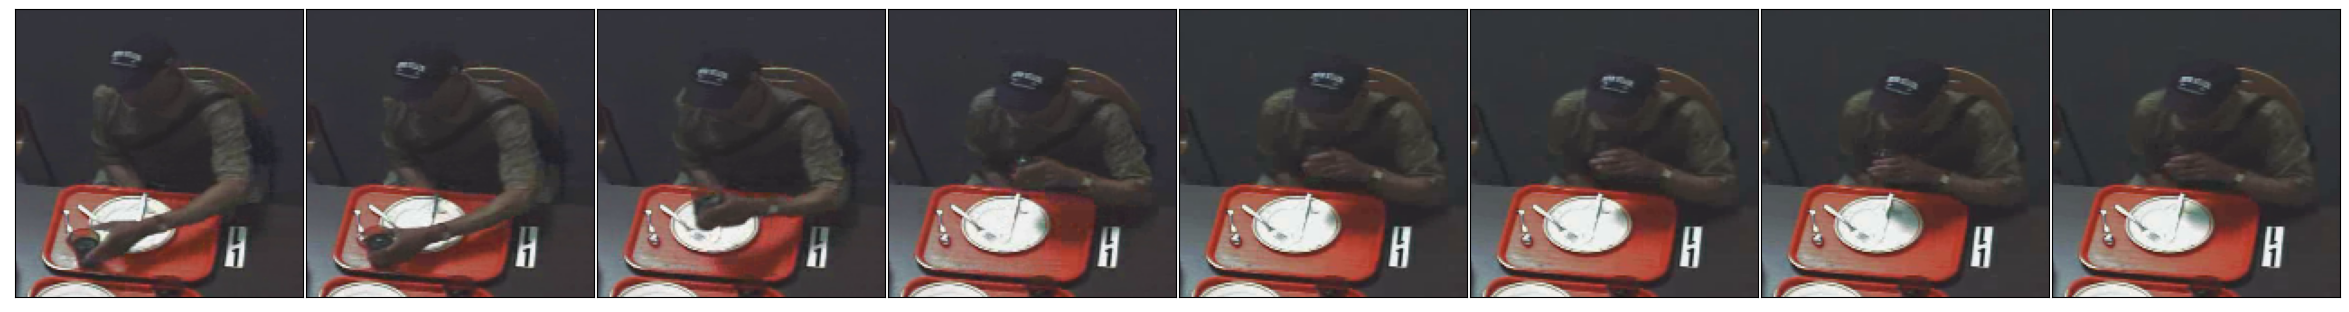

In [13]:
cols = 8
rows = 1
fig=plt.figure(figsize=(30, 5))
# Video idx: p072_c1
# frame idx range: 9 - 4410

# p259_c1:
# 1570-1577
# 5416-5426
for col_idx in range(cols):
    plt.subplot(rows,cols,col_idx+1)
    frame = cv2.imread(f"{data_loc}{video_idx}/frame_{5416+col_idx*2:06}.ppm")
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    plot = plt.imshow(frame)
    plot.axes.get_xaxis().set_visible(False)
    plot.axes.get_yaxis().set_visible(False)

plt.subplots_adjust(wspace=0.01, hspace=-0.6)

plt.savefig('fpExample2.pdf', format='pdf', dpi=500, bbox_inches='tight')    

#### Plot key video pieces - true bite

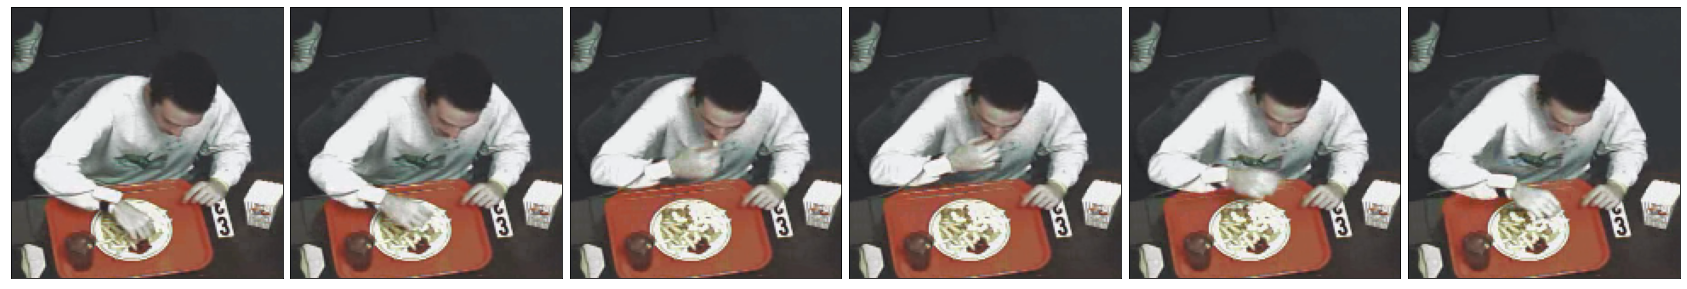

In [56]:
cols = 6
rows = 1
fig=plt.figure(figsize=(30, 5))
# Video idx: p072_c1
# frame idx range: 9 - 4410
for col_idx in range(cols):
    plt.subplot(rows,cols,col_idx+1)
    frame = cv2.imread(f"{data_loc}{video_idx}/frame_{bite_idxs[2][0]+col_idx:06}.ppm")
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    plot = plt.imshow(frame)
    plot.axes.get_xaxis().set_visible(False)
    plot.axes.get_yaxis().set_visible(False)

plt.subplots_adjust(wspace=0.01, hspace=-0.6)

plt.savefig('bite_example.pdf', format='pdf', dpi=500, bbox_inches='tight')    

#### Plot key video pieces - true bite

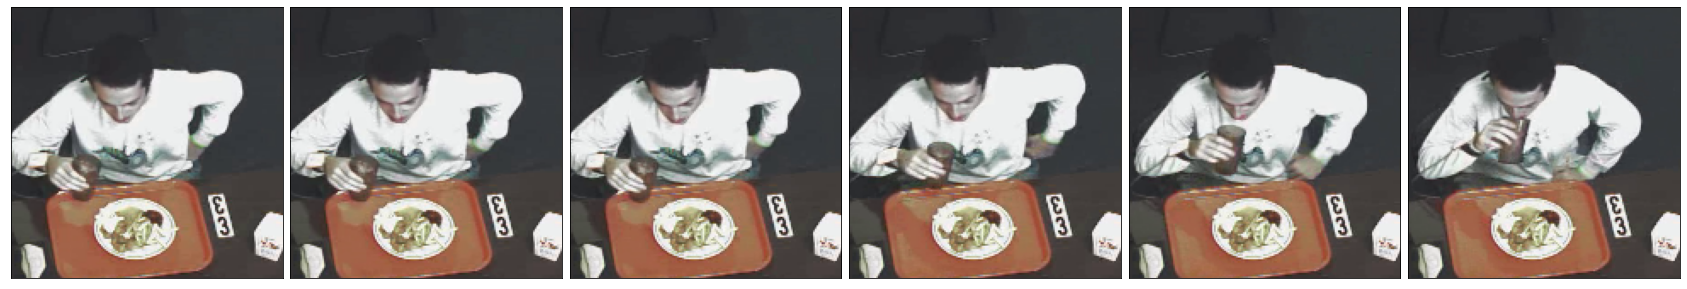

In [65]:
cols = 6
rows = 1
fig=plt.figure(figsize=(30, 5))
# Video idx: p072_c1
# frame idx range: 9 - 4410
for col_idx in range(cols):
    plt.subplot(rows,cols,col_idx+1)
    frame = cv2.imread(f"{data_loc}{video_idx}/frame_{drink_idxs[5][0]+(col_idx-1)*2:06}.ppm")
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    plot = plt.imshow(frame)
    plot.axes.get_xaxis().set_visible(False)
    plot.axes.get_yaxis().set_visible(False)

plt.subplots_adjust(wspace=0.01, hspace=-0.6)

plt.savefig('drink_example2.pdf', format='pdf', dpi=500, bbox_inches='tight')    

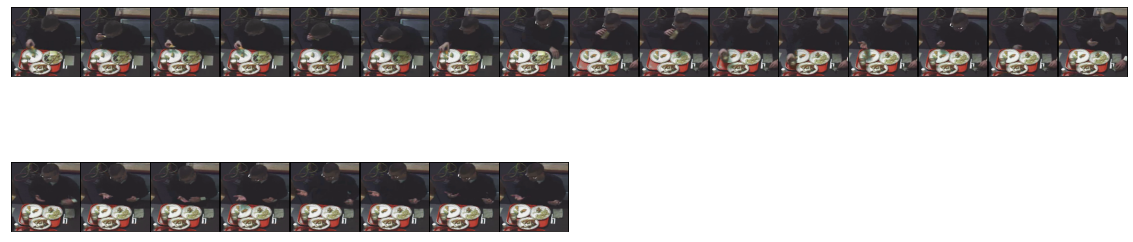

In [14]:
cols = 16
rows = 2
fig=plt.figure(figsize=(20, 10))

for col_idx in range(cols):
    plt.subplot(rows,cols,col_idx+1)
    frame = cv2.imread(f"{data_loc}{video_idx}/frame_{bite_idxs[2][0]+col_idx*4:06}.ppm")
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    plot = plt.imshow(frame)
    plot.axes.get_xaxis().set_visible(False)
    plot.axes.get_yaxis().set_visible(False)
for col_idx in range(cols):
    plt.subplot(rows,cols,col_idx+1+8)
    frame = cv2.imread(f"{data_loc}{video_idx}/frame_{drink_idxs[2][0]+10+col_idx*4:06}.ppm")
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    plot = plt.imshow(frame)
    plot.axes.get_xaxis().set_visible(False)
    plot.axes.get_yaxis().set_visible(False)

plt.subplots_adjust(wspace=0.01, hspace=-0.6)

plt.savefig('motionExample.jpg', format='jpg')    

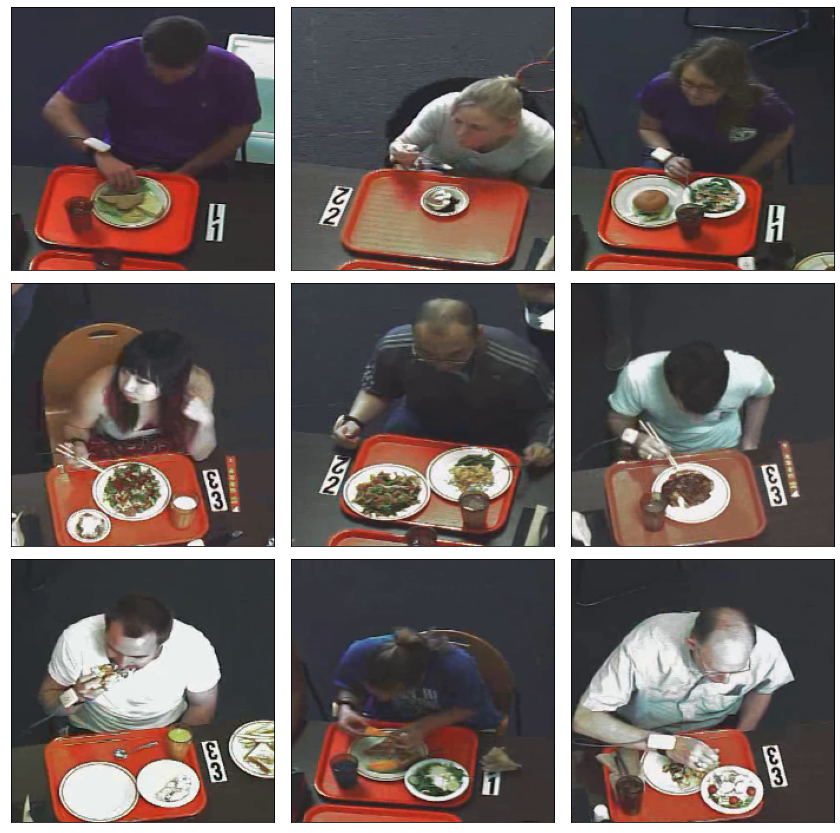

In [11]:
displayed_video_list = ["p007_c1","p017_c2","p020_c1","p180_c1","p048_c1","p082_c2","p122_c1","p185_c1","p257_c1"]
rows = 3
cols = 3
fig=plt.figure(figsize=(15, 15))
for row_idx in range(rows):
    for col_idx in range(cols):
        video_idx = displayed_video_list[row_idx*rows+col_idx]
        start_idx = 0
        f_gt = open(f"{gt_loc}{video_idx}/gt_ges_3labels.txt","r")
        for line in f_gt.readlines():
            info = str.split(str.split(line, "\n")[0], "\t") 
            if info[0] == "bite" or info[0] == "drink":
                start_idx= int(info[1])
                break
        f_gt.close()
        frame = cv2.imread(f"{data_loc}{video_idx}/frame_{start_idx+200:06}.ppm")
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        plt.subplot(rows,cols,rows*row_idx+col_idx+1)
        plot = plt.imshow(frame)
        plot.axes.get_xaxis().set_visible(False)
        plot.axes.get_yaxis().set_visible(False)
        
plt.subplots_adjust(wspace=0.01, hspace=0.05)
plt.savefig('dataExample.png', format='png')    

In [75]:
row_idx*rows+cols

9

In [14]:
p029_c1 = cv2.cvtColor(cv2.imread("p029_c1.jpg"), cv2.COLOR_BGR2RGB)
p029_c1_crop = cv2.cvtColor(cv2.imread("p029_c1_crop.jpg"), cv2.COLOR_BGR2RGB)
p020_c1 = cv2.cvtColor(cv2.imread("p020_c1.jpg"), cv2.COLOR_BGR2RGB)
p020_c1_crop = cv2.cvtColor(cv2.imread("p020_c1_crop.jpg"), cv2.COLOR_BGR2RGB)

In [32]:
p029_c1_crop.shape

(350, 260, 3)

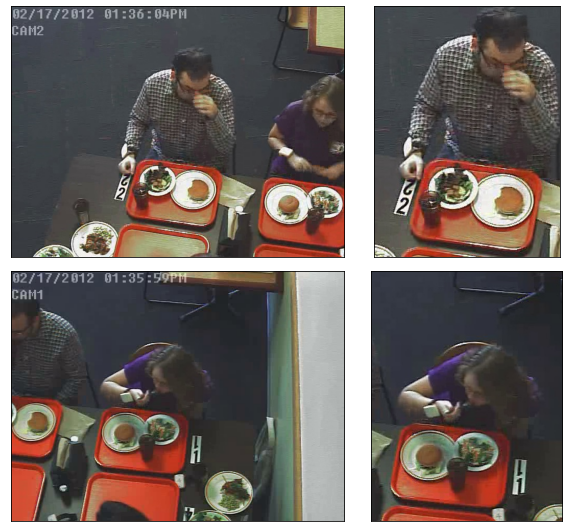

In [42]:
fig=plt.figure(figsize=(10, 7.5))
plt.subplot(2,2,1)
plot = plt.imshow(p029_c1)
plot.axes.get_xaxis().set_visible(False)
plot.axes.get_yaxis().set_visible(False)
plt.subplot(2,2,2)
plot = plt.imshow(p029_c1_crop)
plot.axes.get_xaxis().set_visible(False)
plot.axes.get_yaxis().set_visible(False)
plt.subplot(2,2,3)
plot = plt.imshow(p020_c1)
plot.axes.get_xaxis().set_visible(False)
plot.axes.get_yaxis().set_visible(False)
plt.subplot(2,2,4)
plot = plt.imshow(p020_c1_crop)
plot.axes.get_xaxis().set_visible(False)
plot.axes.get_yaxis().set_visible(False)
plt.savefig('dataFrame.eps', format='eps')    